<a id="import"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:200%; text-align:center; border-radius:20px 20px;">**Centerline Extraction: Method 1**</p>

<a id="import"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Method Overview: Mesh-Based Centerline Extraction (VMTK)</p>

This notebook implements **Method 1** for extracting coronary artery centerlines from binary segmentation masks. This is based on the **Vascular Modeling Toolkit (VMTK)**.

### Pipeline Summary

The algorithm transforms a discrete 3D voxel mask into a continuous geometric representation through the following steps:

1. **Load the binary mask**: Read the `.nrrd` annotation file using **vmtkImageReader**, keeping the data as a native VTK image object.
2. **Marching Cubes**: Convert the binary voxel grid into a continuous 3D triangulated surface using **vmtkMarchingCubes**.
3. **Surface smoothing**: Apply Taubin passband smoothing via **vmtkSurfaceSmoothing** to reduce staircase artifacts while preserving vessel geometry.
4. **Seed point selection**: Identify the source (proximal ostium) and target (distal branch tips) points on the surface.
5. **VMTK Centerline Extraction**: Compute geometrically optimal centerlines using Voronoi diagrams and the maximum inscribed sphere radius at every point along the vessel.

### Key Output

The extracted centerline provides, for every point along the artery:
- **3D spatial coordinates** $(P_x, P_y, P_z)$ in physical space (mm).
- **Maximum Inscribed Sphere Radius**: the largest sphere that fits inside the vessel at that point, which directly relates to the local vessel diameter used for stenosis quantification downstream.

In [1]:
## Imports & Configuration
import sys
import types
from pathlib import Path

import numpy as np
import pyvista as pv
from vmtk import vmtkscripts

# The vmtk conda-forge build strips vtkRenderingMatplotlib to save space.
# PyVista tries to import it for LaTeX text rendering and crashes if missing.
# Injecting a dummy module lets PyVista skip it gracefully.
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

<module 'vtkmodules.vtkRenderingMatplotlib'>

In [2]:
SAMPLE_ID = 1
DATA_ROOT = Path("../data/ASOCA Normal")
NRRD_PATH = DATA_ROOT / "Annotations" / f"Normal_{SAMPLE_ID}.nrrd"

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

print(f"Sample : Normal_{SAMPLE_ID}")
print(f"Path   : {NRRD_PATH}")
print(f"Exists : {NRRD_PATH.exists()}")

Sample : Normal_1
Path   : ..\data\ASOCA Normal\Annotations\Normal_1.nrrd
Exists : True


<a id="import"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Load the Binary Segmentation Mask</p>

We use **vmtkImageReader** to load the `.nrrd` annotation file. This keeps the data as a native VTK image object (`vtkImageData`), preserving all spatial metadata (spacing, origin) and ensuring seamless compatibility with the rest of the VMTK pipeline, so no format conversions needed.

In [3]:
reader = vmtkscripts.vmtkImageReader()
reader.InputFileName = str(NRRD_PATH)
reader.Execute()

vtk_image = reader.Image

print("---------------------------------------------")
print(f"Dimensions (X, Y, Z) : {vtk_image.GetDimensions()}")         # Matrix size of the 3D image. Like a stack of 2D pictures. 
print(f"Spacing (mm)         : {vtk_image.GetSpacing()}")            # In CT images, every 3D pixel is called a voxel. Represents a real physical space in the patients body. This is the size of each voxel.
print(f"Origin (mm)          : {vtk_image.GetOrigin()}")             # The position of the first voxel in the image obtained from the CT scaner of the patient. Like a physical center coordinate. 
print(f"Scalar range         : {vtk_image.GetScalarRange()}")        # The range of values in the binary segmentation mask. 1 is the vessel, 0 is the background.
print(f"Number of points     : {vtk_image.GetNumberOfPoints():,}")   # 512*512*204. Loaded a grid of 53.4 million 3D data points. 

Spacing 0.416016 0.416016 0.625000
Origin 116.800003 120.000000 -196.875000
Dimensions 512 512 204
---------------------------------------------
Dimensions (X, Y, Z) : (512, 512, 204)
Spacing (mm)         : (0.41601600000000005, 0.41601600000000005, 0.6250000000000001)
Origin (mm)          : (116.80000305175783, 120.00000000000003, -196.875)
Scalar range         : (0.0, 1.0)
Number of points     : 53,477,376


### Understanding the Image Metadata

The output above describes the **spatial structure** of the loaded 3D medical image. These parameters are inherited from the original CT scanner and are critical because every geometric calculation in the rest of the pipeline (surface meshes, centerline coordinates, vessel diameters) depends on them.

| Parameter | Value | Meaning |
|-----------|-------|---------|
| **Dimensions** | `(512, 512, 204)` | The size of the 3D voxel grid: 512 voxels along X, 512 along Y, and 204 slices along Z. Think of it as a stack of 204 two-dimensional images, each 512 x 512 pixels. |
| **Spacing (mm)** | `(0.416, 0.416, 0.625)` | The **physical size of each voxel** in millimetres. Each voxel covers 0.416 mm in X and Y (the in-plane resolution of the CT scan) and 0.625 mm in Z (the distance between consecutive slices). This is what converts pixel indices into real-world distances. |
| **Origin (mm)** | `(116.8, 120.0, -196.9)` | The **physical position of the very first voxel** `(0, 0, 0)` inside the patient coordinate system defined by the CT scanner. It anchors the entire grid in 3D space so that all coordinates are expressed relative to the patient's anatomy, not arbitrary pixel indices. |
| **Scalar range** | `(0.0, 1.0)` | The minimum and maximum intensity values in the image. Because this is a **binary segmentation mask**, there are only two values: `0` (background) and `1` (coronary artery). A raw CCTA volume would have a much wider Hounsfield-unit range. |
| **Number of points** | `53,477,376` | The total number of voxels in the grid: $512 \times 512 \times 204 = 53{,}477{,}376$. Each one of these points holds a scalar value (0 or 1) indicating whether it belongs to a coronary artery. |

**Why does this matter?** 
- When we run Marching Cubes in the next step, VMTK uses the **spacing** and **origin** internally to place the resulting surface mesh vertices directly in physical millimetre coordinates. This means every downstream measurement (vessel diameter, centerline length, stenosis percentage) is automatically in clinically meaningful units, and no manual coordinate transforms required.

<a id="import"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Generate the Surface Mesh (Marching Cubes)</p>

We use **vmtkMarchingCubes** to extract a continuous triangulated surface (`vtkPolyData`) from the binary mask. By staying inside the VMTK/VTK ecosystem, the spatial metadata (spacing, origin) is handled automatically and no manual affine transforms or NumPy-to-VTK conversions required.

### How does Marching Cubes work in our case?

Right now our data is a **3D grid of 53 million voxels** where each voxel is either `0` (background) or `1` (coronary artery). We need to turn this blocky Minecraft-like volume into a **smooth continuous surface** that wraps around the artery. That is exactly what Marching Cubes does.

The algorithm slides a small **2 x 2 x 2 cube** (8 neighbouring voxels) across the entire grid, one step at a time. For each cube it asks a simple question: *which of the 8 corners are inside the artery (value $\geq$ 0.5) and which are outside?* Depending on the answer, it looks up a pre-computed table of 256 possible configurations and generates one or more **triangle patches** that approximate the boundary surface at that cube's location.

When the algorithm finishes sweeping the full volume, all the individual triangle patches are stitched together into a single, continuous **triangulated surface mesh**, that is, a `vtkPolyData` object composed of vertices and triangular faces.

- **Key parameter: `Level = 0.5`:** This is the iso-value threshold. Because our mask contains only 0s and 1s, setting the level to 0.5 places the surface exactly at the boundary between the artery and the background. Any voxel corner with value $\geq 0.5$ is considered "inside".

- **Coordinate system:** Because we stay within the VMTK/VTK ecosystem, the algorithm automatically applies the **spacing** and **origin** from the image header. The resulting mesh vertices are placed directly in **physical millimetre coordinates**, the same coordinate system used by the CT scanner, with no manual transforms needed.

In [4]:
marching = vmtkscripts.vmtkMarchingCubes()
marching.Image = vtk_image
marching.Level = 0.5
marching.Execute()

surface_raw = marching.Surface

# Wrap in PyVista for inspection and visualization
mesh_raw = pv.wrap(surface_raw)

print(f"Surface mesh : {mesh_raw.n_points:,} vertices, {mesh_raw.n_cells:,} triangles")
print(f"Bounds (mm)  : X [{mesh_raw.bounds[0]:.1f}, {mesh_raw.bounds[1]:.1f}]  "
      f"Y [{mesh_raw.bounds[2]:.1f}, {mesh_raw.bounds[3]:.1f}]  "
      f"Z [{mesh_raw.bounds[4]:.1f}, {mesh_raw.bounds[5]:.1f}]")

Surface mesh : 37,886 vertices, 75,768 triangles
Bounds (mm)  : X [177.7, 283.0]  Y [173.5, 272.5]  Z [-176.6, -85.9]


### Understanding the Marching Cubes Output

| Parameter | Value | Interpretation |
|-----------|-------|----------------|
| **Vertices** | `37,886` | The number of 3D points that define the surface. Each vertex has $(x, y, z)$ coordinates in physical mm. Out of the original 53 million grid voxels, only those near the artery boundary contribute to the mesh — hence the massive reduction. |
| **Triangles** | `75,768` | The number of triangular faces connecting the vertices. The roughly **2 : 1 ratio** of triangles to vertices is expected for closed triangulated surfaces (a consequence of Euler's formula for polyhedra). |
| **Bounds X** | `[177.7, 283.0]` mm | The physical extent of the artery mesh along the X axis. |
| **Bounds Y** | `[173.5, 272.5]` mm | The physical extent along Y. |
| **Bounds Z** | `[-176.6, -85.9]` mm | The physical extent along Z. |

The mesh bounds `[177.7, 283.0]`, `[173.5, 272.5]`, `[-176.6, -85.9]` fall **well inside** the full volume, which confirms that the coronary artery tree occupies only a sub-region of the chest CT and is exactly what we would expect anatomically.

<a id="import"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. Smooth the Surface Mesh</p>

Raw marching-cubes output has staircase artifacts inherited from the voxel grid. We use **vmtkSurfaceSmoothing** with Taubin-style passband smoothing, which alternates shrinking and inflating passes to reduce noise while minimising volume shrinkage, this is critical for preserving accurate vessel diameters.

### How does Taubin Smoothing work in our case?

The surface we obtained from Marching Cubes looks like a coronary artery tree, but if you zoom in closely, you'll see **staircase-like jagged edges**. These artifacts come from the underlying voxel grid: the surface was forced to follow the square boundaries of the voxels instead of the true curved shape of the vessel.

**vmtkSurfaceSmoothing** fixes this by iteratively adjusting every vertex on the mesh toward the average position of its neighbours. However, naive smoothing (Laplacian) has a well-known problem: it **shrinks** the object with every iteration, the artery would get thinner and shorter, corrupting the geometry we need for accurate diameter measurements.

**Taubin smoothing** solves this by alternating two passes per iteration:
1. **Shrink pass** ($\lambda > 0$): moves each vertex toward its neighbours, smoothing out noise.
2. **Inflate pass** ($\mu < 0$): pushes vertices back outward, compensating for the shrinkage.

The `PassBand` parameter controls which surface frequencies are removed. A value of `0.1` targets high-frequency noise (the voxel staircase) while preserving the low-frequency global shape (the overall vessel diameter and branching structure).

| Parameter | Value | Effect |
|-----------|-------|--------|
| **NumberOfIterations** | `500` | Number of shrink/inflate cycles. More iterations = smoother result. |
| **PassBand** | `0.1` | Frequency cutoff. Lower values smooth more aggressively; `0.1` is a good balance for medical vessel meshes. |

**Why this matters for our pipeline:** The downstream stenosis quantification depends directly on accurate vessel diameters. Taubin smoothing removes the voxel noise without artificially narrowing or widening the artery — preserving the geometric fidelity that the inscribed-radius measurements require.

Smoothed mesh : 37,886 vertices, 75,768 triangles


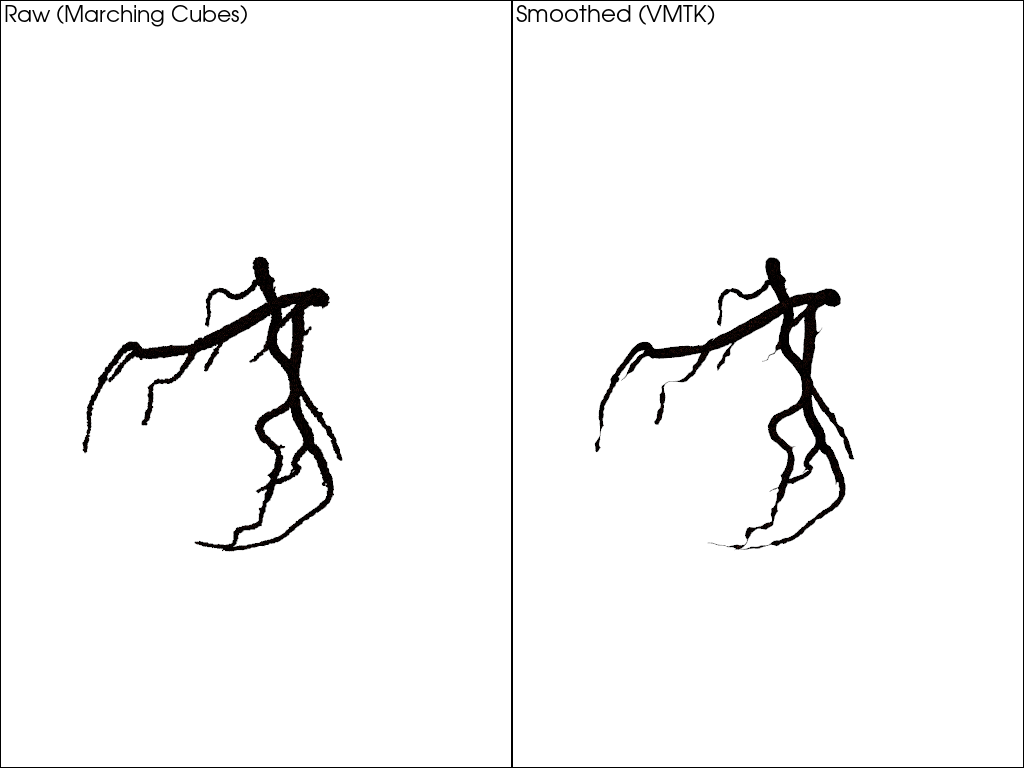

In [7]:
smoother = vmtkscripts.vmtkSurfaceSmoothing()
smoother.Surface = surface_raw
smoother.NumberOfIterations = 500
smoother.PassBand = 0.1
smoother.Execute()

surface_smooth = smoother.Surface

# Wrap in PyVista for visualization
mesh_smooth = pv.wrap(surface_smooth)

print(f"Smoothed mesh : {mesh_smooth.n_points:,} vertices, {mesh_smooth.n_cells:,} triangles")

# Side-by-side comparison: raw vs smoothed
pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_text("Raw (Marching Cubes)", font_size=12)
pl.add_mesh(mesh_raw, color="tomato", show_edges=True)
pl.subplot(0, 1)
pl.add_text("Smoothed (VMTK)", font_size=12)
pl.add_mesh(mesh_smooth, color="tomato", show_edges=True)
pl.link_views()
pl.show()

### Interpreting the Smoothing Result

**Vertex / triangle count:** The smoothed mesh has exactly the same `37,886` vertices and `75,768` triangles as the raw mesh. This is expected, Taubin smoothing only **moves** existing vertices; it does not add or remove any. The mesh topology (how triangles connect) is preserved.

**Visual comparison (side-by-side):** Both panels show the same coronary artery tree from the same viewpoint. The differences are subtle at this zoom level because the smoothing targets **high-frequency noise**, not the overall shape. If you zoom into a branch, you would see the right panel has noticeably rounder, cleaner edges compared to the blocky left panel. The global structure (branch lengths, angles, diameters) remains virtually identical, which confirms the volume-preserving property of Taubin smoothing is working as intended.

<a id="import"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">5. Visualize & Select Seed Points</p>

VMTK's centerline algorithm requires **seed points** on the vessel surface:

- **Source point**: The proximal origin of the artery (ostium, where the coronary artery exits the aorta).
- **Target points**: The distal tips of each branch you want to trace.

The cell below renders the mesh interactively. **Rotate the view** to identify the ostium and the branch endpoints. The code also prints the 5 most extremal surface points (farthest from the mesh centroid) as starting candidates.

> **Workflow:** Run the visualization below, identify the coordinates, then fill them into the configuration cell that follows.

Candidate extremal points (farthest from centroid):

  #1  [  178.68,   184.79,  -163.60]   dist = 71.36 mm
  #2  [  178.84,   184.54,  -163.56]   dist = 71.36 mm
  #3  [  178.49,   185.07,  -163.62]   dist = 71.36 mm
  #4  [  178.75,   185.08,  -163.98]   dist = 71.36 mm
  #5  [  178.50,   185.41,  -163.96]   dist = 71.35 mm


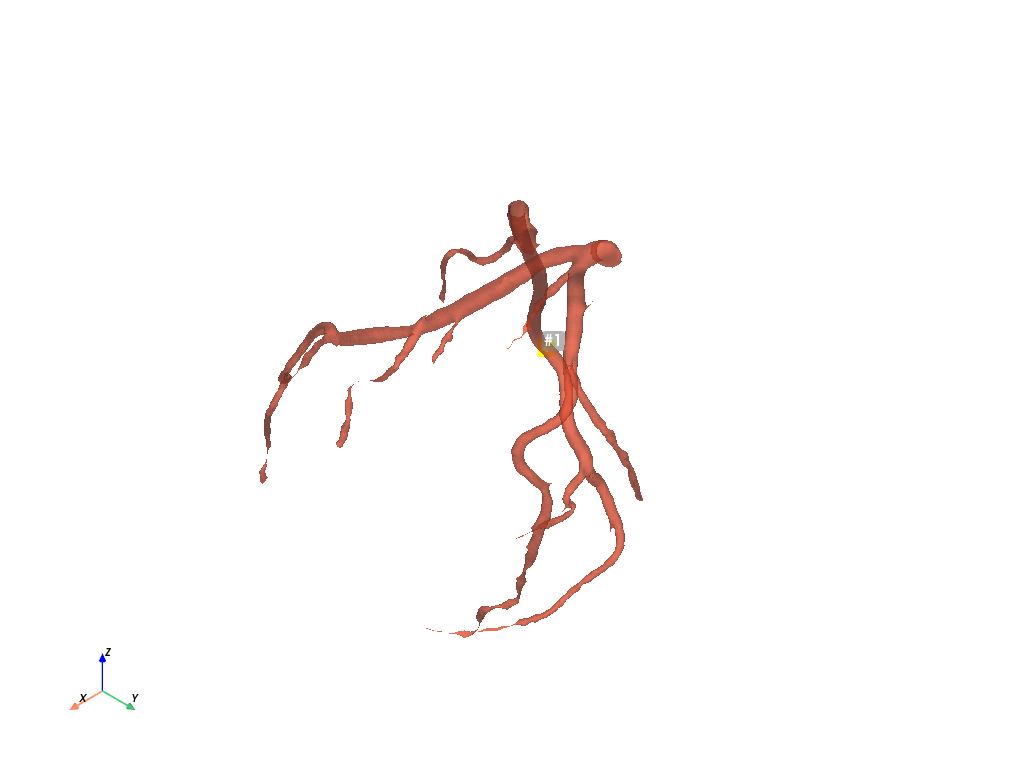

In [8]:
points = mesh_smooth.points
centroid = points.mean(axis=0)
dists = np.linalg.norm(points - centroid, axis=1)

# Candidate extremal points (likely branch tips or ostium)
top_idx = np.argsort(dists)[-5:][::-1]
print("Candidate extremal points (farthest from centroid):\n")
for rank, idx in enumerate(top_idx, 1):
    p = points[idx]
    print(f"  #{rank}  [{p[0]:8.2f}, {p[1]:8.2f}, {p[2]:8.2f}]   "
          f"dist = {dists[idx]:.2f} mm")

# Interactive 3D view with labeled candidates
pl = pv.Plotter()
pl.add_mesh(mesh_smooth, color="tomato", opacity=0.6, show_edges=False)
pl.add_point_labels(
    points[top_idx],
    [f"#{i}" for i in range(1, len(top_idx) + 1)],
    font_size=16,
    point_size=15,
    point_color="yellow",
    text_color="white",
    shape_opacity=0.6,
    always_visible=True,
)
pl.add_axes()
pl.show()

### Configure Seed Points

After inspecting the mesh above, enter the **source** (ostium) and **target** (branch tips) coordinates below. Replace the placeholder `[0.0, 0.0, 0.0]` values with the coordinates you identified. The code will automatically snap them to the nearest vertex on the surface.

In [9]:
# ============================================================
# EDIT THESE COORDINATES after inspecting the mesh above
# ============================================================

# Source: the proximal ostium (one point)
source_point = [0.0, 0.0, 0.0]          # <-- REPLACE with ostium coordinates

# Targets: distal branch tips (add as many as needed)
target_points = [
    [0.0, 0.0, 0.0],                    # <-- REPLACE: branch tip 1
    [0.0, 0.0, 0.0],                    # <-- REPLACE: branch tip 2
]

# Snap to the nearest surface vertex for robustness
def snap_to_surface(mesh, point):
    """Return the coordinates of the closest vertex on the mesh."""
    idx = mesh.find_closest_point(point)
    return mesh.points[idx].tolist()

source_snapped = snap_to_surface(mesh_smooth, source_point)
targets_snapped = [snap_to_surface(mesh_smooth, t) for t in target_points]

print(f"Source  (snapped) : {[f'{c:.2f}' for c in source_snapped]}")
for i, t in enumerate(targets_snapped, 1):
    print(f"Target {i} (snapped) : {[f'{c:.2f}' for c in t]}")

# Flatten into the format VMTK expects: [x1, y1, z1, x2, y2, z2, ...]
source_flat = source_snapped
targets_flat = [coord for pt in targets_snapped for coord in pt]

Source  (snapped) : ['190.07', '182.13', '-126.32']
Target 1 (snapped) : ['190.07', '182.13', '-126.32']
Target 2 (snapped) : ['190.07', '182.13', '-126.32']


## 5. Extract Centerlines with VMTK

We pass the smoothed surface and the seed points to VMTK's **vmtkCenterlines** algorithm. Internally it:

1. Computes a **Voronoi diagram** of the enclosed volume.
2. Determines the **maximum inscribed sphere** at every interior point.
3. Traces the geometrically optimal **centerline path** from source to each target along the Voronoi ridge.

The output is a polyline with point-wise data including `MaximumInscribedSphereRadius` — the key geometric quantity for downstream stenosis quantification ($\%DS$).

In [10]:
centerline_filter = vmtkscripts.vmtkCenterlines()
centerline_filter.Surface = surface_smooth
centerline_filter.SeedSelectorName = "pointlist"
centerline_filter.SourcePoints = source_flat
centerline_filter.TargetPoints = targets_flat
centerline_filter.AppendEndPoints = 1
centerline_filter.Execute()

centerlines_vtk = centerline_filter.Centerlines
voronoi_vtk = centerline_filter.VoronoiDiagram

centerlines = pv.wrap(centerlines_vtk)

print(f"Centerline extracted : {centerlines.n_points} points, "
      f"{centerlines.n_cells} segments")
print(f"Point data arrays    : {list(centerlines.point_data.keys())}")

Cleaning surface.
Triangulating surface.
Computing centerlines.
Computing centerlines...Centerline extracted : 8 points, 2 segments
Point data arrays    : ['MaximumInscribedSphereRadius']


In [11]:
cl_points = centerlines.points
cl_radii = centerlines.point_data["MaximumInscribedSphereRadius"]

print(f"Centerline length    : {centerlines.length:.2f} mm")
print(f"Number of points     : {len(cl_points)}")
print(f"Radius range         : [{cl_radii.min():.3f}, {cl_radii.max():.3f}] mm")
print(f"Mean radius          : {cl_radii.mean():.3f} mm")
print(f"\nFirst 5 centerline points:")
for i in range(min(5, len(cl_points))):
    p = cl_points[i]
    print(f"  [{p[0]:8.2f}, {p[1]:8.2f}, {p[2]:8.2f}]  "
          f"r = {cl_radii[i]:.3f} mm")

Centerline length    : 0.68 mm
Number of points     : 8
Radius range         : [0.684, 0.684] mm
Mean radius          : 0.684 mm

First 5 centerline points:
  [  190.62,   182.45,  -126.59]  r = 0.684 mm
  [  190.62,   182.45,  -126.59]  r = 0.684 mm
  [  190.62,   182.45,  -126.59]  r = 0.684 mm
  [  190.62,   182.45,  -126.59]  r = 0.684 mm
  [  190.07,   182.13,  -126.32]  r = 0.684 mm


## 6. Results Visualization

Final interactive 3D view showing the transparent artery surface with the extracted centerline colored by the **maximum inscribed sphere radius** (local vessel size in mm). The source (ostium) is marked in green and the branch-tip targets in red.

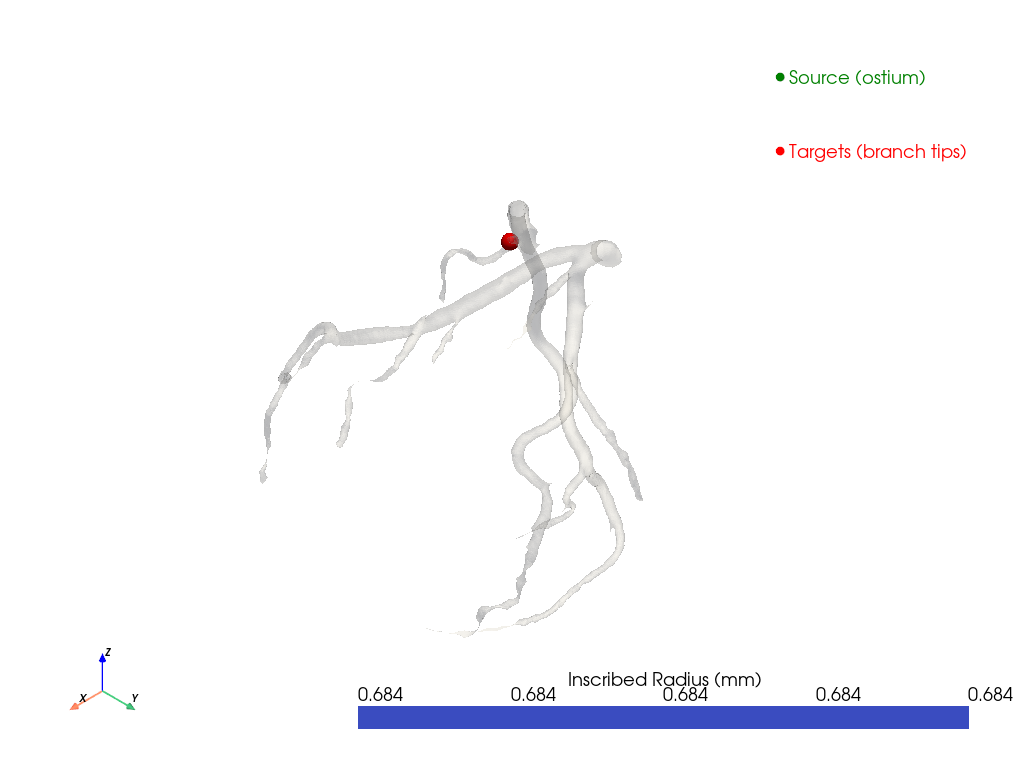

In [12]:
pl = pv.Plotter()

# Transparent artery surface
pl.add_mesh(mesh_smooth, color="white", opacity=0.25, show_edges=False)

# Centerline as a tube, colored by inscribed radius
centerlines["Radius (mm)"] = cl_radii
tube = centerlines.tube(radius=0.3)
pl.add_mesh(
    tube,
    scalars="Radius (mm)",
    cmap="coolwarm",
    scalar_bar_args={"title": "Inscribed Radius (mm)", "n_labels": 5},
)

# Mark source and target seed points
pl.add_points(
    np.array([source_snapped]),
    color="green",
    point_size=18,
    render_points_as_spheres=True,
    label="Source (ostium)",
)
pl.add_points(
    np.array(targets_snapped),
    color="red",
    point_size=18,
    render_points_as_spheres=True,
    label="Targets (branch tips)",
)

pl.add_legend(bcolor="white", face="circle")
pl.add_axes()
pl.show()